In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('raw_data.csv')

df.head()

,Customer_ID,Name,Age,City,Salary,Joining_Date
0,101,Rahul,25,Hyderabad,45000.0,12-01-2023
1,102,Priya,27,Chennai,52000.0,12-02-2023
2,103,Arjun,NaN,Bangalore,60000.0,Mar 15 2023
3,104,Sneha,29,Mumbai,NaN,18-04-2023
4,105,Kiran,31,Delhi,55000.0,18-05-2023


In [3]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customer_ID   10 non-null     int64  
 1   Name          9 non-null      object 
 2   Age           9 non-null      object 
 3   City          9 non-null      object 
 4   Salary        9 non-null      float64
 5   Joining_Date  10 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 612.0+ bytes


,0
Customer_ID,0
Name,1
Age,1
City,1
Salary,1
Joining_Date,0


In [4]:
df = df.drop_duplicates()

print(df.shape)

(9, 6)


In [5]:
df['Name'] = df['Name'].fillna('Unknown')

df['City'] = df['City'].fillna(df['City'].mode()[0])

In [6]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df['Age'] = df['Age'].fillna(df['Age'].median())

In [7]:
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

In [8]:
df['Joining_Date'] = pd.to_datetime(
    df['Joining_Date'],
    errors='coerce'
)

df['Joining_Date'] = df['Joining_Date'].dt.strftime('%Y-%m-%d')

In [9]:
print(df.isnull().sum())

df.head()

Customer_ID     0
Name            0
Age             0
City            0
Salary          0
Joining_Date    7
dtype: int64


,Customer_ID,Name,Age,City,Salary,Joining_Date
0,101,Rahul,25.0,Hyderabad,45000.0,2023-12-01
1,102,Priya,27.0,Chennai,52000.0,2023-12-02
2,103,Arjun,27.0,Bangalore,60000.0,NaN
3,104,Sneha,29.0,Mumbai,52625.0,NaN
4,105,Kiran,31.0,Delhi,55000.0,NaN


In [15]:
from google.colab import files
df.to_csv('cleaned_dataset.csv', index=False)
files.download('cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

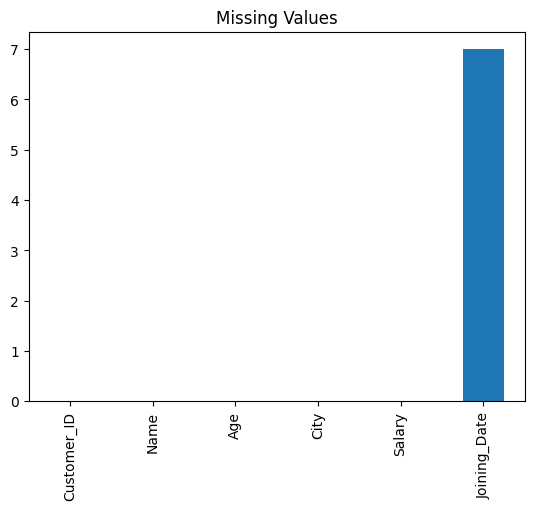

In [16]:
import matplotlib.pyplot as plt

df.isnull().sum().plot(
    kind='bar'
)

plt.title('Missing Values')
plt.show()